Perform supplementary validation analysis of detection sequence, using the 50 minute delay between NOAA20 and SNPP. Are candidate vs. known detections from one sensor similarly likely to be associated with detections from an adjacent overpass?

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime as dt
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
#optional for visualization
from lonboard import viz, Map, ScatterplotLayer, PolygonLayer
from lonboard.colormap import apply_continuous_cmap

In [3]:
cols = ['longitude', 'latitude', 'fire_mask', 'confidence', 'acq_date',
       'acq_time', 'acq_datetime', 'vza', 'daynight', 'frp', 'geometry', 'satellite', 
        'fireid', 'name']
dets = gpd.read_parquet('/projects/shared-buckets/coffield/viirs/outputs/western_us/joined_dets_2020.parquet', 
                       columns=cols)
dets

,longitude,latitude,fire_mask,confidence,acq_date,acq_time,acq_datetime,vza,daynight,frp,geometry,satellite,fireid,name
0,-117.324610,33.329407,2.0,x,2020-06-19,20:42,2020-06-19 20:42:00+00:00,11.07150,D,-1.182707,POINT (-117.32461 33.32941),SNPP,F7672,None
1,-117.336655,33.347225,8.0,n,2020-06-10,08:48,2020-06-10 08:48:00+00:00,47.46070,N,2.425918,POINT (-117.33665 33.34723),SNPP,F7672,None
2,-117.345110,33.347466,8.0,n,2020-06-10,10:30,2020-06-10 10:30:00+00:00,52.76080,N,3.217252,POINT (-117.34511 33.34747),SNPP,F7672,None
3,-117.340454,33.347492,8.0,n,2020-06-10,08:48,2020-06-10 08:48:00+00:00,47.46960,N,2.425918,POINT (-117.34045 33.34749),SNPP,F7672,None
4,-117.344450,33.347782,9.0,h,2020-06-10,08:48,2020-06-10 08:48:00+00:00,47.47850,N,5.945793,POINT (-117.34445 33.34778),SNPP,F7672,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873857,-119.165764,37.553604,8.0,n,2020-11-03,09:00,2020-11-03 09:00:00+00:00,46.08230,N,0.687182,POINT (-119.16576 37.55360),NOAA20,F12649,CREEK
873858,-119.078804,37.554460,8.0,n,2020-11-16,10:00,2020-11-16 10:00:00+00:00,20.14210,N,0.808999,POINT (-119.07880 37.55446),NOAA20,F12649,CREEK
873859,-119.158820,37.556786,8.0,n,2020-11-05,21:24,2020-11-05 21:24:00+00:00,41.06680,D,4.264699,POINT (-119.15882 37.55679),NOAA20,F12649,CREEK
873860,-119.164820,37.559460,8.0,n,2020-11-05,10:06,2020-11-05 10:06:00+00:00,27.10520,N,2.125922,POINT (-119.16482 37.55946),NOAA20,F12649,CREEK


<h3>Common grid - round to 0.005 latitude/longitude (~500m)</h3>

In [7]:
dets['lon500'] = (dets.longitude*2).round(2)/2
dets['lat500'] = (dets.latitude*2).round(2)/2

In [4]:
dets['lon1'] = dets.longitude.round(2)
dets['lat1'] = dets.latitude.round(2)

In [5]:
dets.head()

,longitude,latitude,fire_mask,confidence,acq_date,acq_time,acq_datetime,vza,daynight,frp,geometry,satellite,fireid,name,lon1,lat1
0,-117.324610,33.329407,2.0,x,2020-06-19,20:42,2020-06-19 20:42:00+00:00,11.0715,D,-1.182707,POINT (-117.32461 33.32941),SNPP,F7672,None,-117.32,33.33
1,-117.336655,33.347225,8.0,n,2020-06-10,08:48,2020-06-10 08:48:00+00:00,47.4607,N,2.425918,POINT (-117.33665 33.34723),SNPP,F7672,None,-117.34,33.35
2,-117.345110,33.347466,8.0,n,2020-06-10,10:30,2020-06-10 10:30:00+00:00,52.7608,N,3.217252,POINT (-117.34511 33.34747),SNPP,F7672,None,-117.35,33.35
3,-117.340454,33.347492,8.0,n,2020-06-10,08:48,2020-06-10 08:48:00+00:00,47.4696,N,2.425918,POINT (-117.34045 33.34749),SNPP,F7672,None,-117.34,33.35
4,-117.344450,33.347782,9.0,h,2020-06-10,08:48,2020-06-10 08:48:00+00:00,47.4785,N,5.945793,POINT (-117.34445 33.34778),SNPP,F7672,None,-117.34,33.35


<h3>Group by shared date, day-vs-night, and grid cell.</h3>Count instances of known/cand/none within 60min of NOAA20 dets

In [6]:
grouped = dets.groupby(['acq_date','daynight','lon1','lat1']) #or lat1, lon1

In [7]:
for g in grouped:
    print(g)
    stop

(('2020-06-01', 'D', -103.46, 37.39),        longitude   latitude  fire_mask confidence    acq_date acq_time  \
33978 -103.45649  37.388905        9.0          h  2020-06-01    20:30   

                   acq_datetime      vza daynight        frp  \
33978 2020-06-01 20:30:00+00:00  44.8818        D  38.226139   

                          geometry satellite fireid  name    lon1   lat1  
33978  POINT (-103.45649 37.38891)    NOAA20  F7046  None -103.46  37.39  )


NameError: name 'stop' is not defined

In [8]:
g[1]

,longitude,latitude,fire_mask,confidence,acq_date,acq_time,acq_datetime,vza,daynight,frp,geometry,satellite,fireid,name,lon1,lat1
33978,-103.45649,37.388905,9.0,h,2020-06-01,20:30,2020-06-01 20:30:00+00:00,44.8818,D,38.226139,POINT (-103.45649 37.38891),NOAA20,F7046,None,-103.46,37.39


<h2>Main approach: sensor-agnostic, both forward & backward-looking</h2>
Go through groups, for every detection, note backward & forward-looking matches and their average vza

In [ ]:
%%time 

for name, g in grouped:
    for det in g.index: #loop through each det
        #print(det)
        if g.loc[det, 'fire_mask'] >=7:
            code = 'K'
        else: code = 'C'

        t = g.loc[det, 'acq_datetime']
        t_diffs = g.acq_datetime - t
        
        #look for preceding dets
        matches = g[(t_diffs < dt.timedelta(minutes=0)) & (t_diffs > dt.timedelta(minutes=-60))]
        
        if len(matches)==0:
            precode = 'N' + code
        else:
            matches_type = matches.fire_mask
            if (matches_type < 7).any() and (matches_type >= 7).any():
                precode = 'B' + code #both
            elif (matches_type < 7).any():
                precode = 'C' + code
            elif (matches_type >= 7).any():
                precode = 'K' + code
            dets.loc[det, 'pre_vza'] = matches.vza.mean() #new

        dets.loc[det, 'pre_dets'] = precode
        
        #look for subsequent dets
        matches = g[(t_diffs > dt.timedelta(minutes=0)) & (t_diffs < dt.timedelta(minutes=60))]
        
        if len(matches)==0:
            postcode = code + 'N'
        else:
            matches_type = matches.fire_mask
            if (matches_type < 7).any() and (matches_type >= 7).any():
                postcode = code + 'B' #both
            elif (matches_type < 7).any():
                postcode = code + 'C'
            elif (matches_type >= 7).any():
                postcode = code + 'K'
            dets.loc[det, 'post_vza'] = matches.vza.mean() #new

        dets.loc[det, 'post_dets'] = postcode
        
        #if det==33971: stop

dets.to_parquet('/projects/my-public-bucket/viirs/outputs/western_us/joined_dets_2020_sequence_both_1km.parquet', index=False)

In [40]:
dets.to_parquet('/projects/my-public-bucket/viirs/outputs/western_us/joined_dets_2020_sequence_both.parquet', index=False)

In [3]:
dets = pd.read_parquet('/projects/my-public-bucket/viirs/outputs/western_us/joined_dets_2020_sequence_both.parquet')

In [16]:
dets

,longitude,latitude,fire_mask,confidence,acq_date,acq_time,acq_datetime,vza,daynight,frp,geometry,satellite,fireid,name,lon500,lat500,pre_dets,post_dets,post_vza,pre_vza
0,-117.324610,33.329407,2.0,x,2020-06-19,20:42,2020-06-19 20:42:00+00:00,11.07150,D,-1.182707,b'\x01\x01\x00\x00\x00\x18}\x05i\xc6T]\xc0h\t2...,SNPP,F7672,None,-117.325,33.330,NC,CN,NaN,NaN
1,-117.336655,33.347225,8.0,n,2020-06-10,08:48,2020-06-10 08:48:00+00:00,47.46070,N,2.425918,b'\x01\x01\x00\x00\x00;\xc2i\xc1\x8bU]\xc0C\xa...,SNPP,F7672,None,-117.335,33.345,NK,KN,NaN,NaN
2,-117.345110,33.347466,8.0,n,2020-06-10,10:30,2020-06-10 10:30:00+00:00,52.76080,N,3.217252,b'\x01\x01\x00\x00\x00r\xe1@H\x16V]\xc0h<\x11\...,SNPP,F7672,None,-117.345,33.345,NK,KN,NaN,NaN
3,-117.340454,33.347492,8.0,n,2020-06-10,08:48,2020-06-10 08:48:00+00:00,47.46960,N,2.425918,b'\x01\x01\x00\x00\x00\xb6\xf2\x92\xff\xc9U]\x...,SNPP,F7672,None,-117.340,33.345,NK,KK,11.658400,NaN
4,-117.344450,33.347782,9.0,h,2020-06-10,08:48,2020-06-10 08:48:00+00:00,47.47850,N,5.945793,b'\x01\x01\x00\x00\x00\xdcF\x03x\x0bV]\xc0\x99...,SNPP,F7672,None,-117.345,33.350,NK,KK,11.613967,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873857,-119.165764,37.553604,8.0,n,2020-11-03,09:00,2020-11-03 09:00:00+00:00,46.08230,N,0.687182,b'\x01\x01\x00\x00\x00\xaa\xb6\x9b\xe0\x9b\xca...,NOAA20,F12649,CREEK,-119.165,37.555,NK,KK,10.884700,NaN
873858,-119.078804,37.554460,8.0,n,2020-11-16,10:00,2020-11-16 10:00:00+00:00,20.14210,N,0.808999,b'\x01\x01\x00\x00\x00\xd1\xb2\xee\x1f\x0b\xc5...,NOAA20,F12649,CREEK,-119.080,37.555,NK,KN,NaN,NaN
873859,-119.158820,37.556786,8.0,n,2020-11-05,21:24,2020-11-05 21:24:00+00:00,41.06680,D,4.264699,b'\x01\x01\x00\x00\x00\xd9|\\\x1b*\xca]\xc0ro~...,NOAA20,F12649,CREEK,-119.160,37.555,NK,KN,NaN,NaN
873860,-119.164820,37.559460,8.0,n,2020-11-05,10:06,2020-11-05 10:06:00+00:00,27.10520,N,2.125922,b'\x01\x01\x00\x00\x00\x83n/i\x8c\xca]\xc0\xc8...,NOAA20,F12649,CREEK,-119.165,37.560,KK,KN,NaN,37.2963


Stats of interest:
- Proportion of K vs C dets associated with a K or C in either direction
- When a C is NOT associated with another detection, what is its view angle wrt average?

In [11]:
#((1km version)) --------------------------
knowns = dets[dets.fire_mask>6]
cands = dets[dets.fire_mask<7]

matching_knowns = knowns[(knowns.pre_dets.str[0]!='N') | (knowns.post_dets.str[1]!='N')]
matching_cands = cands[(cands.pre_dets.str[0]!='N') | (cands.post_dets.str[1]!='N')]

unmatching_knowns = knowns[(knowns.pre_dets.str[0]=='N') & (knowns.post_dets.str[1]=='N')]
unmatching_cands = cands[(cands.pre_dets.str[0]=='N') & (cands.post_dets.str[1]=='N')]


print('%knowns with a match:', len(matching_knowns)/len(knowns))
print('%candidates with a match:', len(matching_cands)/len(cands))


#vza of candidates that match vs. don't 
print('Mean VZA of candidates that have match', matching_cands.vza.mean())
print('Mean VZA of candidates that dont have match', unmatching_cands.vza.mean())

print('Mean VZA of knowns that have match', matching_knowns.vza.mean())
print('Mean VZA of knowns that dont have match', unmatching_knowns.vza.mean())

%knowns with a match: 0.8801190024841697
%candidates with a match: 0.7169283652521768
Mean VZA of candidates that have match 30.837554392266764
Mean VZA of candidates that dont have match 30.572765258522498
Mean VZA of knowns that have match 32.4309392641634
Mean VZA of knowns that dont have match 30.724254410218197


In [5]:
#500m version (main) ----------------------------
knowns = dets[dets.fire_mask>6]
cands = dets[dets.fire_mask<7]

matching_knowns = knowns[(knowns.pre_dets.str[0]!='N') | (knowns.post_dets.str[1]!='N')]
matching_cands = cands[(cands.pre_dets.str[0]!='N') | (cands.post_dets.str[1]!='N')]

unmatching_knowns = knowns[(knowns.pre_dets.str[0]=='N') & (knowns.post_dets.str[1]=='N')]
unmatching_cands = cands[(cands.pre_dets.str[0]=='N') & (cands.post_dets.str[1]=='N')]


print('%knowns with a match:', len(matching_knowns)/len(knowns))
print('%candidates with a match:', len(matching_cands)/len(cands))


#vza of candidates that match vs. don't 
print('Mean VZA of candidates that have match', matching_cands.vza.mean())
print('Mean VZA of candidates that dont have match', unmatching_cands.vza.mean())

print('Mean VZA of knowns that have match', matching_knowns.vza.mean())
print('Mean VZA of knowns that dont have match', unmatching_knowns.vza.mean())

%knowns with a match: 0.7229457500325376
%candidates with a match: 0.5223431904471033
Mean VZA of candidates that have match 31.249866163568512
Mean VZA of candidates that dont have match 30.22974867647502
Mean VZA of knowns that have match 32.41351362816277
Mean VZA of knowns that dont have match 31.737929525924848


In [6]:
#figures

cands_pre = cands.pre_dets.str[0]
cands_post = cands.post_dets.str[1]

pre_values, pre_counts = np.unique(cands_pre, return_counts=True)
post_values, post_counts  = np.unique(cands_post, return_counts=True)

post_values, post_counts

(array(['B', 'C', 'K', 'N'], dtype=object),
 array([  3229,  18231,  27710, 117816]))

In [9]:
pre_values, pre_counts

(array(['B', 'C', 'K', 'N'], dtype=object),
 array([  3221,  18239,  27573, 117953]))

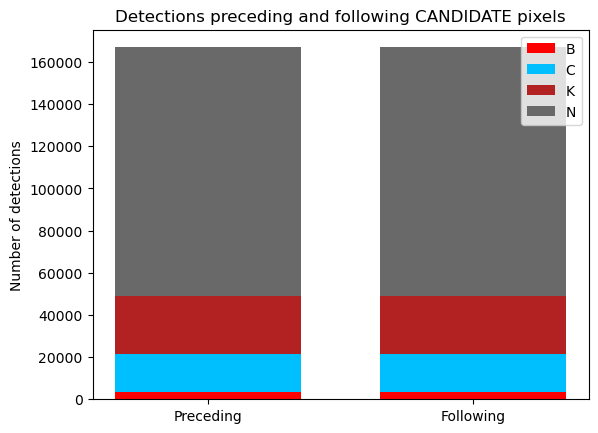

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.bar(['Preceding','Following'], [pre_counts[0],post_counts[0]], 0.7, label='B', color='red')
ax.bar(['Preceding','Following'], [pre_counts[1],post_counts[1]], 0.7, label='C', bottom=[pre_counts[0],post_counts[0]], color='deepskyblue')
ax.bar(['Preceding','Following'], [pre_counts[2],post_counts[2]], 0.7, label='K', bottom=[pre_counts[0]+pre_counts[1], post_counts[0]+post_counts[1]], color='firebrick')
ax.bar(['Preceding','Following'], [pre_counts[3],post_counts[3]], 0.7, label='N', bottom=[pre_counts[0]+pre_counts[1]+pre_counts[2], post_counts[0]+post_counts[1]+post_counts[2]], color='dimgray')

#ax.set_title("Number of penguins with above average body mass")
ax.legend(loc="upper right")
ax.set_ylabel('Number of detections')
ax.set_title('Detections preceding and following CANDIDATE pixels')

plt.show()

In [30]:
#double check sums
labels, counts = np.unique(cands.pre_dets.str[0] + cands.post_dets.str[1], return_counts=True)
labels, counts

(array(['BB', 'BC', 'BK', 'BN', 'CB', 'CC', 'CK', 'CN', 'KB', 'KC', 'KK',
        'KN', 'NB', 'NC', 'NK', 'NN'], dtype=object),
 array([   31,   194,   303,  2693,   159,  1599,  1615, 14866,   353,
         1947,  4778, 20495,  2686, 14491, 21014, 79762]))

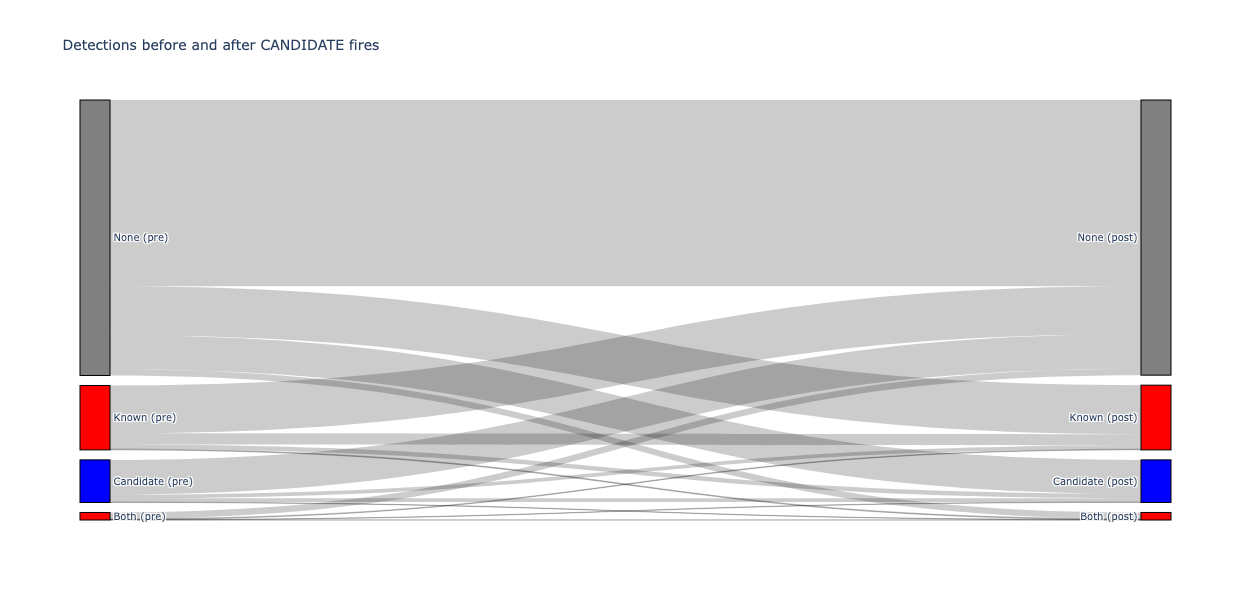

In [50]:
names = ['B1','C1','K1','N1','B2','C2','K2','N2']

import plotly.graph_objects as go

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 10,
      thickness = 30,
      line = dict(color = "black", width = 1),
      label = ['Both (pre)','Candidate (pre)','Known (pre)','None (pre)','Both (post)','Candidate (post)','Known (post)','None (post)'],
      color = ['red','blue','red','gray','red','blue','red','gray']
    ),
    link = dict(
      source = [0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3], # indices correspond to labels, eg A1, A2, A1, B1, ...
      target = [4,5,6,7,4,5,6,7,4,5,6,7,4,5,6,7],
      value = counts
  ))])

fig.update_layout(title_text="Detections before and after CANDIDATE fires", font_size=10)
fig.update_layout(
    autosize=False,  # Set to False to ensure explicit width/height are respected
    width=800,       # Set the desired width in pixels
    height=600       # Set the desired height in pixels
)
fig.write_html('/projects/my-public-bucket/viirs/outputs/western_us/joined_dets_2020_sequence_sankey.html')
fig.show()

In [51]:
79800 / len(cands)

0.4778843735402968

In [52]:
#again for knowns - sankey

#double check sums
labels, counts = np.unique(knowns.pre_dets.str[0] + knowns.post_dets.str[1], return_counts=True)
labels, counts

(array(['BB', 'BC', 'BK', 'BN', 'CB', 'CC', 'CK', 'CN', 'KB', 'KC', 'KK',
        'KN', 'NB', 'NC', 'NK', 'NN'], dtype=object),
 array([    36,    271,   1091,   6286,    282,   1432,   4449,  19768,
          1323,   4957,  70379, 187636,   6549,  18650, 187924, 195843]))

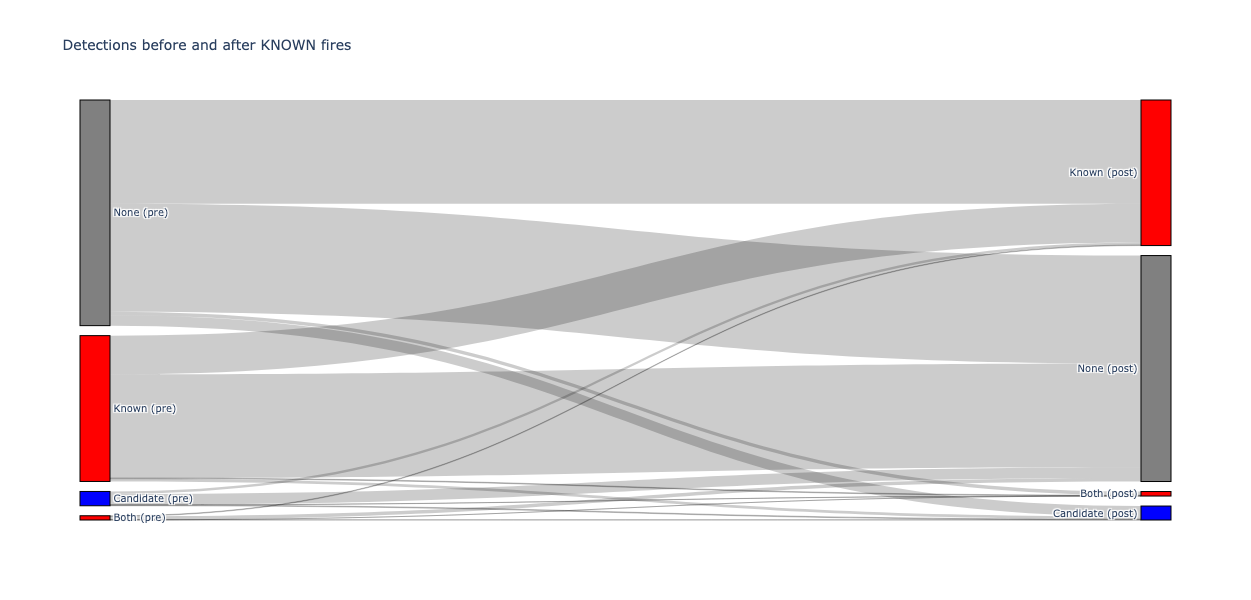

In [53]:
names = ['B1','C1','K1','N1','B2','C2','K2','N2']

import plotly.graph_objects as go

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 10,
      thickness = 30,
      line = dict(color = "black", width = 1),
      label = ['Both (pre)','Candidate (pre)','Known (pre)','None (pre)','Both (post)','Candidate (post)','Known (post)','None (post)'],
      color = ['red','blue','red','gray','red','blue','red','gray']
    ),
    link = dict(
      source = [0,0,0,0,1,1,1,1,2,2,2,2,3,3,3,3], # indices correspond to labels, eg A1, A2, A1, B1, ...
      target = [4,5,6,7,4,5,6,7,4,5,6,7,4,5,6,7],
      value = counts
  ))])

fig.update_layout(title_text="Detections before and after KNOWN fires", font_size=10)
fig.update_layout(
    autosize=False,  # Set to False to ensure explicit width/height are respected
    width=800,       # Set the desired width in pixels
    height=600       # Set the desired height in pixels
)
#fig.write_html('/projects/my-public-bucket/viirs/outputs/western_us/joined_dets_2020_sequence_sankey.html')
fig.show()

In [43]:
#figures

knowns_pre = knowns.pre_dets.str[0]
knowns_post = knowns.post_dets.str[1]

pre_values, pre_counts = np.unique(knowns_pre, return_counts=True)
post_values, post_counts  = np.unique(knowns_post, return_counts=True)

post_values, post_counts

(array(['B', 'C', 'K', 'N'], dtype=object),
 array([  8190,  25310, 263843, 409533]))

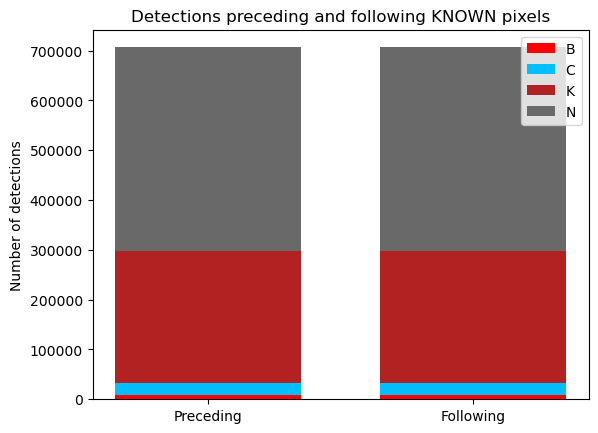

In [44]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

ax.bar(['Preceding','Following'], [pre_counts[0],post_counts[0]], 0.7, label='B', color='red')
ax.bar(['Preceding','Following'], [pre_counts[1],post_counts[1]], 0.7, label='C', bottom=[pre_counts[0],post_counts[0]], color='deepskyblue')
ax.bar(['Preceding','Following'], [pre_counts[2],post_counts[2]], 0.7, label='K', bottom=[pre_counts[0]+pre_counts[1], post_counts[0]+post_counts[1]], color='firebrick')
ax.bar(['Preceding','Following'], [pre_counts[3],post_counts[3]], 0.7, label='N', bottom=[pre_counts[0]+pre_counts[1]+pre_counts[2], post_counts[0]+post_counts[1]+post_counts[2]], color='dimgray')

#ax.set_title("Number of penguins with above average body mass")
ax.legend(loc="upper right")
ax.set_ylabel('Number of detections')
ax.set_title('Detections preceding and following KNOWN pixels')

plt.show()

In [45]:
len(cands) / (len(cands) + len(knowns))

0.1910896686204458

In [55]:
#about the same number of pre and post agreement
(~np.isnan(cands.post_vza)).sum(), (~np.isnan(cands.pre_vza)).sum()

(74229, 74354)

Text(0.5, 0, 'VZA difference (deg)')

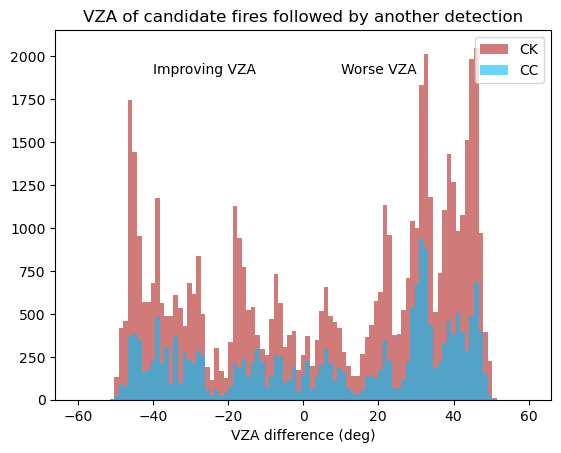

In [80]:
fig, ax = plt.subplots()

bins = numpy.linspace(-60, 60, 100)

cc = cands[cands.post_dets=='CC']
ck = cands[(cands.post_dets=='CK') | (cands.post_dets=='CB')]

ax.hist(ck.post_vza - ck.vza, bins, alpha=0.6, label='CK', color='firebrick')
ax.hist(cc.post_vza - cc.vza, bins, alpha=0.6, label='CC', color='deepskyblue')

ax.legend(loc='upper right')

ax.text(-40, 1900, 'Improving VZA')
ax.text(10, 1900, 'Worse VZA')
ax.set_title('VZA of candidate fires followed by another detection')
ax.set_xlabel('VZA difference (deg)')

In [79]:
(cc.post_vza - cc.vza).mean()

7.253302950839615

<h2>Other approaches (old)</h2>
Go through groups, for any that have NOAA20 detections, look for subsequent SNPP dets within 50 min

In [ ]:
%%time 

for name, g in grouped:
    if g.satellite.str.contains('NOAA20').sum() > 0: #any NOAA20 dets
        for det in g[g.satellite=='NOAA20'].index: #loop through each NOAA20 det
            #print(det)
            if g.loc[det, 'fire_mask'] >=7:
                code = 'K'
            else: code = 'C'
            
            #next look for subsequent dets
            t = g.loc[det, 'acq_datetime']
            snpp = g[(g.satellite=='SNPP')]
            if len(snpp)==0:
                code += 'N'
            else:
                time_differences = snpp.acq_datetime - t
                matches = snpp[(time_differences < dt.timedelta(minutes=60)) & (time_differences > dt.timedelta(minutes=0))]
                if len(matches)==0:
                    code += 'N'
                else:
                    matches_type = matches.fire_mask
                    if (matches_type < 7).any() and (matches_type >= 7).any():
                        code += 'B' #both
                    elif (matches_type < 7).any():
                        code += 'C'
                    elif (matches_type >= 7).any():
                        code += 'K'
                    dets.loc[det, 'next_vza'] = matches.vza.mean() #new
            
            dets.loc[det, 'sequence'] = code 

            #if code=='CC': stop
            #if len(codes) > 20: stop


In [30]:
g

,longitude,latitude,fire_mask,confidence,acq_date,acq_time,acq_datetime,vza,daynight,frp,geometry,satellite,fireid,name,lon1,lat1,lon500,lat500,sequence
872165,-118.38148,36.35698,8.0,n,2020-11-28,08:42,2020-11-28 08:42:00+00:00,52.8141,N,2.147913,POINT (-118.38148 36.35698),SNPP,F11825,CASTLE,-118.38,36.36,-118.38,36.355,NaN


In [31]:
#500m grid
#dets.to_parquet('/projects/my-public-bucket/viirs/outputs/western_us/joined_dets_2020_sequenceNOAA20.parquet', index=False)
#1km grid
#dets.to_parquet('/projects/my-public-bucket/viirs/outputs/western_us/joined_dets_2020_sequenceNOAA20_1km.parquet', index=False)

In [32]:
dets

,longitude,latitude,fire_mask,confidence,acq_date,acq_time,acq_datetime,vza,daynight,frp,geometry,satellite,fireid,name,lon1,lat1,lon500,lat500,sequence,next_vza
0,-117.324610,33.329407,2.0,x,2020-06-19,20:42,2020-06-19 20:42:00+00:00,11.07150,D,-1.182707,POINT (-117.32461 33.32941),SNPP,F7672,None,-117.32,33.33,-117.325,33.330,NaN,NaN
1,-117.336655,33.347225,8.0,n,2020-06-10,08:48,2020-06-10 08:48:00+00:00,47.46070,N,2.425918,POINT (-117.33665 33.34723),SNPP,F7672,None,-117.34,33.35,-117.335,33.345,NaN,NaN
2,-117.345110,33.347466,8.0,n,2020-06-10,10:30,2020-06-10 10:30:00+00:00,52.76080,N,3.217252,POINT (-117.34511 33.34747),SNPP,F7672,None,-117.35,33.35,-117.345,33.345,NaN,NaN
3,-117.340454,33.347492,8.0,n,2020-06-10,08:48,2020-06-10 08:48:00+00:00,47.46960,N,2.425918,POINT (-117.34045 33.34749),SNPP,F7672,None,-117.34,33.35,-117.340,33.345,NaN,NaN
4,-117.344450,33.347782,9.0,h,2020-06-10,08:48,2020-06-10 08:48:00+00:00,47.47850,N,5.945793,POINT (-117.34445 33.34778),SNPP,F7672,None,-117.34,33.35,-117.345,33.350,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873857,-119.165764,37.553604,8.0,n,2020-11-03,09:00,2020-11-03 09:00:00+00:00,46.08230,N,0.687182,POINT (-119.16576 37.55360),NOAA20,F12649,CREEK,-119.17,37.55,-119.165,37.555,KK,10.8847
873858,-119.078804,37.554460,8.0,n,2020-11-16,10:00,2020-11-16 10:00:00+00:00,20.14210,N,0.808999,POINT (-119.07880 37.55446),NOAA20,F12649,CREEK,-119.08,37.55,-119.080,37.555,KN,NaN
873859,-119.158820,37.556786,8.0,n,2020-11-05,21:24,2020-11-05 21:24:00+00:00,41.06680,D,4.264699,POINT (-119.15882 37.55679),NOAA20,F12649,CREEK,-119.16,37.56,-119.160,37.555,KN,NaN
873860,-119.164820,37.559460,8.0,n,2020-11-05,10:06,2020-11-05 10:06:00+00:00,27.10520,N,2.125922,POINT (-119.16482 37.55946),NOAA20,F12649,CREEK,-119.16,37.56,-119.165,37.560,KN,NaN


<h3>Analyze results</h3>

In [2]:
dets = gpd.read_parquet('/projects/shared-buckets/coffield/viirs/outputs/western_us/joined_dets_2020_sequenceNOAA20.parquet') 

In [3]:
def calc_results(df):
    vals, counts = np.unique(df['sequence'].astype(str), return_counts=True)
    results = dict(zip(vals, counts))
    print(results)
    print(results['CN'] / (results['CB']+results['CC']+results['CK']+results['CN']),
         'of Candidates are followed by None')
    print(results['KN'] / (results['KB']+results['KC']+results['KK']+results['KN']),
         'of Knowns are followed by None')

    print((results['CK'] + results['CB']) / (results['CB']+results['CC']+results['CK']+results['CN']),
         'of Candidates are followed by Known')
    print((results['KK'] + results['KB']) / (results['KB']+results['KC']+results['KK']+results['KN']),
         'of Knowns are followed by Known')

In [4]:
calc_results(dets)

{'CB': 1754, 'CC': 9214, 'CK': 15417, 'CN': 57038, 'KB': 3749, 'KC': 11326, 'KK': 133344, 'KN': 200395, 'None': 441625}
0.6837203169389736 of Candidates are followed by None
0.574503890325503 of Knowns are followed by None
0.2058305263536435 of Candidates are followed by Known
0.3930260826687002 of Knowns are followed by Known


In [ ]:
#VZA sequence
vza = dets[dets.next_vza > 0]
vza['vza_diff'] = vza.next_vza - vza.vza
vza = vza.iloc[:,-7:]
vza.groupby('sequence').mean()

In [49]:
dets.columns

Index(['longitude', 'latitude', 'fire_mask', 'confidence', 'acq_date',
       'acq_time', 'acq_datetime', 'vza', 'daynight', 'frp', 'geometry',
       'satellite', 'fireid', 'name', 'lon500', 'lat500', 'pre_dets',
       'post_dets', 'post_vza', 'pre_vza'],
      dtype='object')

In [53]:
vza.groupby('sequence').std()

,lon1,lat1,lon500,lat500,next_vza,vza_diff
sequence,,,,,,
CB,5.925376,3.261457,5.925363,3.261432,16.945516,32.514524
CC,5.860330,3.315287,5.860276,3.315295,16.704080,31.574972
CK,5.552397,3.257061,5.552345,3.257051,16.058057,30.720470
KB,5.420121,3.355972,5.420106,3.355943,17.322863,33.017026
KC,5.500807,3.486901,5.500790,3.486912,16.702346,31.245041
KK,5.120736,3.335332,5.120727,3.335321,16.861415,32.130149


Would be helpful to have the "Nones" vza as well. Generally though candidates and knowns behave similarly wrt VZA

In [55]:
dets[['vza','sequence']].groupby('sequence').mean()

,vza
sequence,
CB,29.377284
CC,27.323652
CK,25.076002
CN,34.219975
KB,30.560270
KC,26.532601
KK,28.517057
KN,38.016502


In [56]:
dets.vza.mean()

31.94663457418987

In [11]:
calc_results(dets)

{'CB': 1754, 'CC': 9214, 'CK': 15417, 'CN': 57038, 'KB': 3749, 'KC': 11326, 'KK': 133344, 'KN': 200395, 'None': 441625}
0.6837203169389736 of Candidates are followed by None
0.574503890325503 of Knowns are followed by None
0.2058305263536435 of Candidates are followed by Known
0.3930260826687002 of Knowns are followed by Known


In [29]:
#creek fire only -----------------------
creek = dets[dets.name=='CREEK']
len(creek)

99749

In [30]:
calc_results(creek)

{'CB': 204, 'CC': 1190, 'CK': 1690, 'CN': 7175, 'KB': 406, 'KC': 1224, 'KK': 14519, 'KN': 23844, 'None': 49497}
0.6993859050589726 of Candidates are followed by None
0.5962043357587578 of Knowns are followed by None
0.18461838385807583 of Candidates are followed by Known
0.37319030830395317 of Knowns are followed by Known


In [49]:
#restrict to candidates with VZA < 40
subset = dets[(dets.vza < 40) | (dets.fire_mask>6)]
#subset = dets[dets.vza < 40]
len(subset)

812734

In [50]:
calc_results(subset)

{'CB': 1133, 'CC': 6638, 'CK': 11129, 'CN': 34980, 'KB': 3749, 'KC': 11326, 'KK': 133344, 'KN': 200395, 'None': 410040}
0.6492204899777283 of Candidates are followed by None
0.574503890325503 of Knowns are followed by None
0.2275798069784707 of Candidates are followed by Known
0.3930260826687002 of Knowns are followed by Known


In [ ]:
#next steps to try:
#reverse order - SNPP K/C preceded by K/C/N in NOAA20

#alternatively: only negative validation if view angle is higher?
#Incorporate view angle of first vs. second - mean for CN, KN, etc.
#Bias for SNPP to have a better/worse view than NOAA20? But shouldn't affect C > K

Text(0, 0.5, 'Frequency')

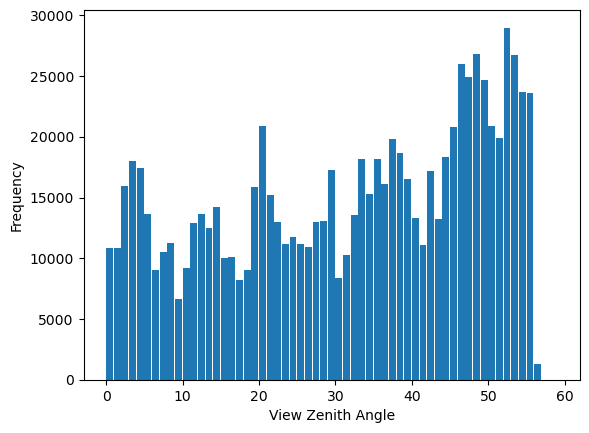

In [202]:
import matplotlib.pyplot as plt
plt.hist(dets.vza, bins=np.arange(0,60,1), width=0.9)
plt.xlabel('View Zenith Angle')
plt.ylabel('Frequency')

Text(0.5, 0, 'scan position')

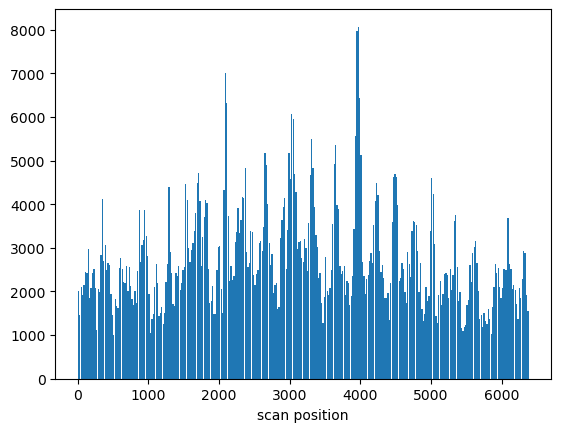

In [203]:
dets2 = gpd.read_parquet('/projects/shared-buckets/coffield/viirs/outputs/western_us/joined_dets_2020.parquet')
plt.hist(dets2.j, bins=np.arange(0,6400,20), width=18)
plt.xlabel('scan position')

<h3>Creek fire play-by-play

In [59]:
dets = gpd.read_parquet('/projects/shared-buckets/coffield/viirs/outputs/western_us/joined_dets_2020_sequenceNOAA20.parquet') 
dets = dets[dets.name=='CREEK']
dets.acq_datetime

250773   2020-09-16 09:54:00+00:00
250774   2020-09-15 19:54:00+00:00
250775   2020-09-16 09:54:00+00:00
250776   2020-09-15 10:12:00+00:00
250777   2020-09-15 21:36:00+00:00
                    ...           
873857   2020-11-03 09:00:00+00:00
873858   2020-11-16 10:00:00+00:00
873859   2020-11-05 21:24:00+00:00
873860   2020-11-05 10:06:00+00:00
873861   2020-11-01 09:42:00+00:00
Name: acq_datetime, Length: 99749, dtype: datetime64[ns, UTC]

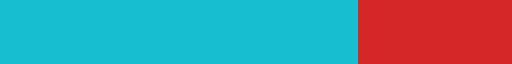

In [66]:
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy

newcolors = [mpl.colormaps['tab10'](c) for c in [9,9,9,9,9,9,9,3,3,3]] 
newcmp = ListedColormap(newcolors)
newcmp

In [124]:
from matplotlib.lines import Line2D

blue = mpl.colormaps['tab10'](9) 
red = mpl.colormaps['tab10'](3) 
colors = {'CN': 'mediumspringgreen',
      'CC': 'lightseagreen',
      'CK': 'royalblue',
      'CB': 'royalblue',
      'KN': 'darkorange',
      'KC': 'orangered',
      'KK': 'darkred',
      'KB': 'darkred'}

legend_elements = []

for c in colors:
    legend_elements.append(Line2D([0], [0], marker='o', color=colors[c], label=c, linestyle='None', markersize=8))

In [180]:
dets = dets.sort_values('acq_datetime')
dn_remap = {'D':'1 Daytime', 'N':'0 Nighttime'}
dets['daytimenighttime'] = dets.daynight.map(dn_remap)

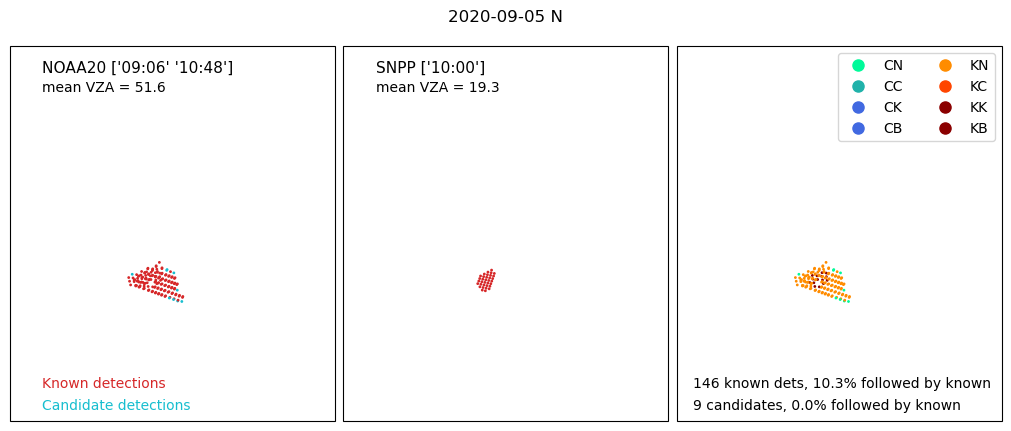

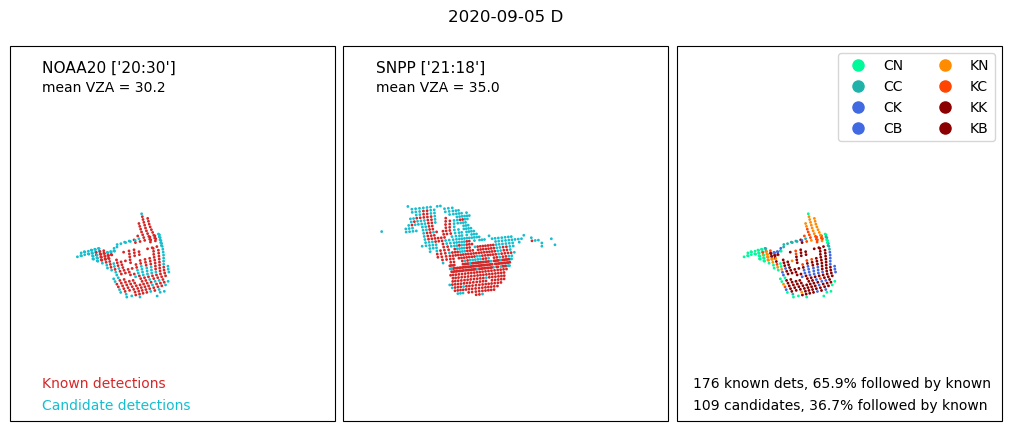

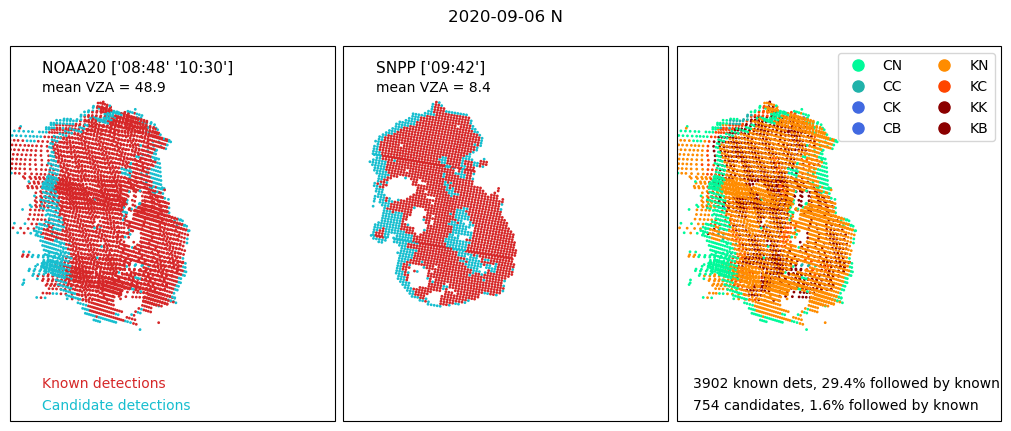

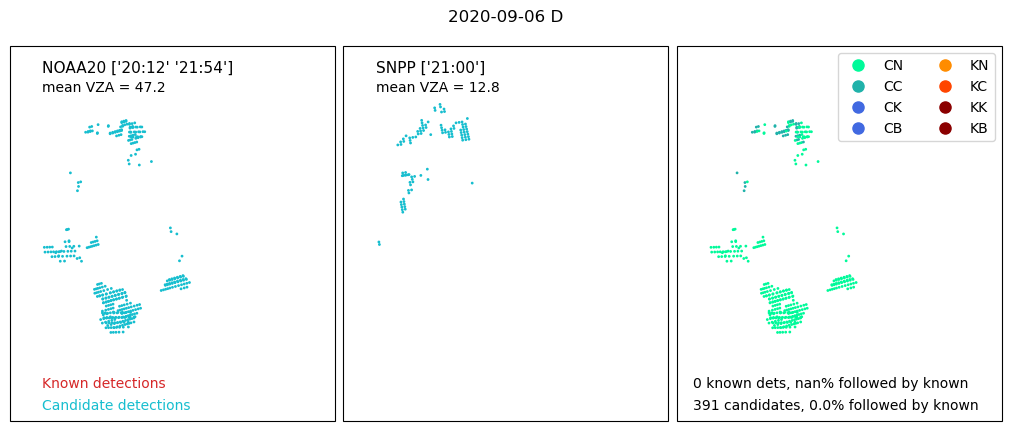

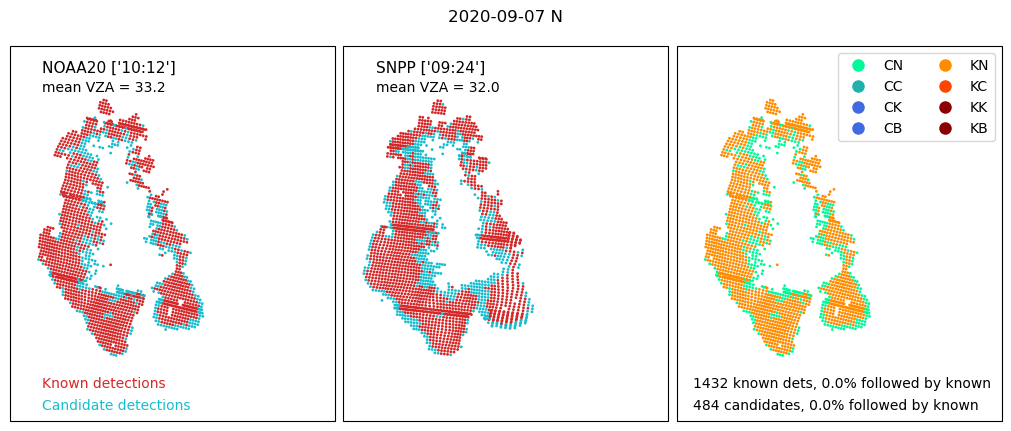

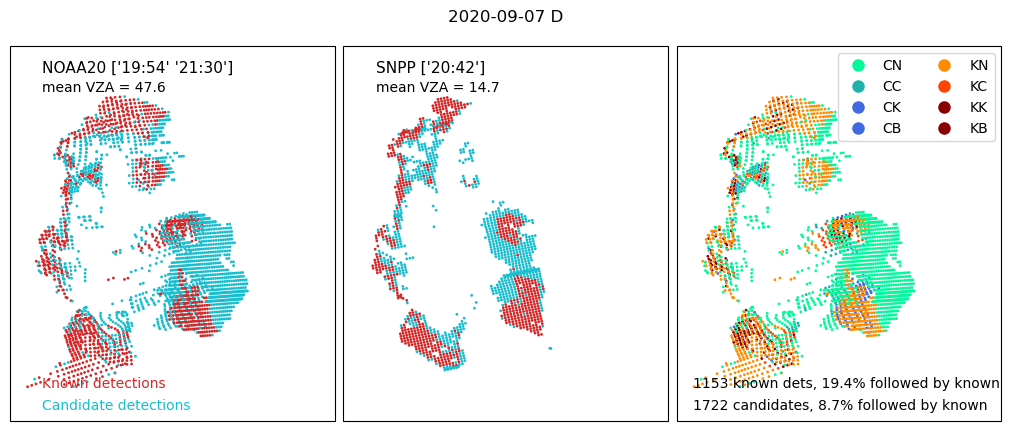

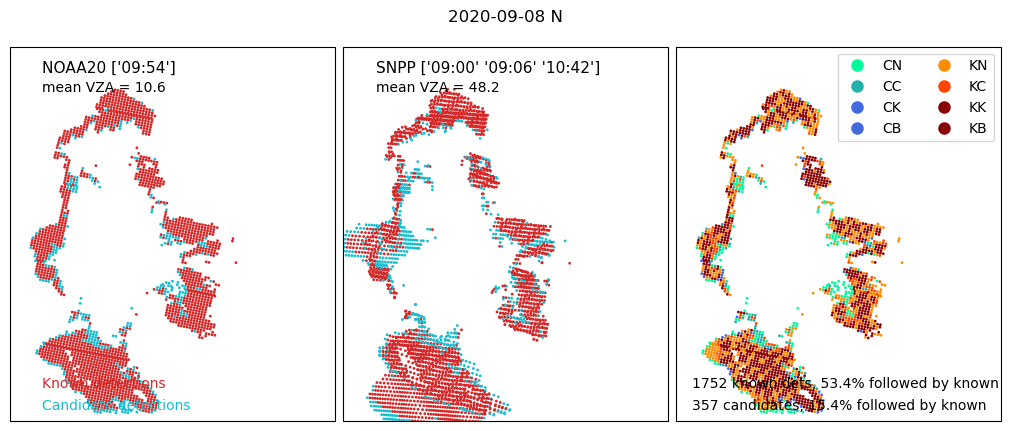

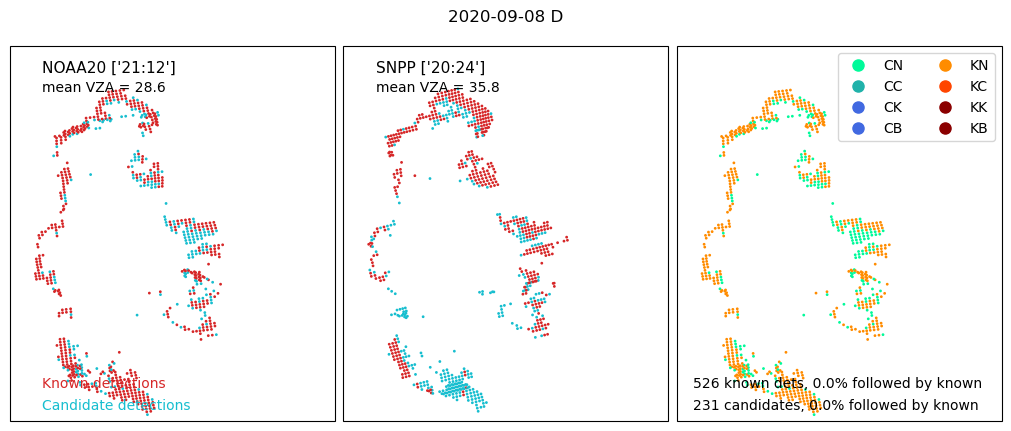

In [181]:
extent = [-119.6,-118.9,36.9,37.6] #creek zoomed
extent = [-119.5,-119,37,37.5]

grouped = dets.groupby(['acq_date','daytimenighttime'])

cycles = 0
for name, g in grouped:
    cycles+=1

    noaa = g[g.satellite=='NOAA20']
    snpp = g[g.satellite=='SNPP']
    n_cands = len(noaa[noaa.fire_mask<7])
    n_known = len(noaa[noaa.fire_mask>6])
    n_CKB = ((noaa.sequence=='CK') | (noaa.sequence=='CB')).sum()
    n_KKB = ((noaa.sequence=='KK') | (noaa.sequence=='KB')).sum()

    fig, axes = plt.subplots(1,3, subplot_kw={'projection': ccrs.Miller()}, constrained_layout=True, figsize=(10,7))
    axes = axes.flatten()
    for ax in axes:
        ax.set_extent(extent)

    day, t = g.iloc[0, [4,8]]
    plt.suptitle(f'{day} {t}', y=0.82)
    
    axes[0].scatter(noaa.longitude, noaa.latitude, c=newcmp(noaa.fire_mask.astype(int)), s=1, transform=ccrs.Geodetic())
    axes[0].annotate(f'NOAA20 {np.unique(noaa.acq_time)}', xy=(0.1, 0.93),  size=11, xycoords=axes[0].transAxes)
    axes[0].annotate(f'mean VZA = {noaa.vza.mean():.1f}', xy=(0.1, 0.88),  size=10, xycoords=axes[0].transAxes)
    axes[0].annotate('Candidate detections', xy=(0.1, 0.03),  size=10, xycoords=axes[0].transAxes, color=blue)
    axes[0].annotate('Known detections', xy=(0.1, 0.09),  size=10, xycoords=axes[0].transAxes, color=red)

    axes[1].scatter(snpp.longitude, snpp.latitude, c=newcmp(snpp.fire_mask.astype(int)), s=1, transform=ccrs.Geodetic())
    axes[1].annotate(f'SNPP {np.unique(snpp.acq_time)}', xy=(0.1, 0.93),  size=11, xycoords=axes[1].transAxes)
    axes[1].annotate(f'mean VZA = {snpp.vza.mean():.1f}', xy=(0.1, 0.88),  size=10, xycoords=axes[1].transAxes)

    noaa['color'] = noaa.sequence.map(colors)
    axes[2].scatter(noaa.longitude, noaa.latitude, c=noaa.color, s=1, transform=ccrs.Geodetic())
    axes[2].legend(handles=legend_elements, loc='upper right', ncols=2)
    axes[2].annotate(f'{n_cands} candidates, {n_CKB/n_cands*100:.1f}% followed by known', xy=(0.05, 0.03),  size=10, xycoords=axes[2].transAxes)#, color=blue)
    axes[2].annotate(f'{n_known} known dets, {n_KKB/n_known*100:.1f}% followed by known', xy=(0.05, 0.09),  size=10, xycoords=axes[2].transAxes)#, color=red)

    if cycles>7: break

In [166]:
len(dets[dets.vza<40]) / len(dets)

0.6043268604196533

<h2>Approach 2</h2>
Satellite-agnostic. Both forward-looking and backward looking for pairs within 60 min. For each row within a group, look for C/K/N dets with 0 < time_diff < 60min -> dets_ahead and -60 < time_diff < 0 -> dets_behind

In [ ]:
%%time 
counts = 0

for name, g in grouped:
    print('group', counts)
    for det in g.index:
        t = dets.loc[det, 'acq_datetime']
        subset_ahead = g[(g.acq_datetime-t > dt.timedelta(0)) & (g.acq_datetime-t < dt.timedelta(seconds=3600))]

        if len(subset_ahead)>0:
            results = np.unique(subset_ahead.confidence)
            if 'x' in results:
                dets.loc[det, 'dets_ahead'] = 'C'
            else: 
                dets.loc[det, 'dets_ahead'] = 'K'
            if ('x' in results) and ('l' in results or 'n' in results or 'h' in results):
                dets.loc[det, 'dets_ahead'] = 'B'
            
        else:
            dets.loc[det, 'dets_ahead'] = 'N'


        subset_behind = g[(g.acq_datetime-t < dt.timedelta(0)) & (g.acq_datetime-t > dt.timedelta(seconds=-3600))]

        if len(subset_behind)>0:
            results = np.unique(subset_behind.confidence)
            if 'x' in results:
                dets.loc[det, 'dets_behind'] = 'C'
            else: 
                dets.loc[det, 'dets_behind'] = 'K'
            if ('x' in results) and ('l' in results or 'n' in results or 'h' in results):
                dets.loc[det, 'dets_behind'] = 'B'
            
        else:
            dets.loc[det, 'dets_behind'] = 'N'


    counts = counts+1
    #if counts>10: stop
    #if det==17400: stop
    
dets.to_parquet('/projects/my-public-bucket/viirs/outputs/western_us/joined_dets_2020_sequenceboth_1km.parquet', index=False)


group 0
group 1
group 2
group 3
group 4
group 5
group 6
group 7
group 8
group 9
group 10
group 11
group 12
group 13
group 14
group 15
group 16
group 17
group 18
group 19
group 20
group 21
group 22
group 23
group 24
group 25
group 26
group 27
group 28
group 29
group 30
group 31
group 32
group 33
group 34
group 35
group 36
group 37
group 38
group 39
group 40
group 41
group 42
group 43
group 44
group 45
group 46
group 47
group 48
group 49
group 50
group 51
group 52
group 53
group 54
group 55
group 56
group 57
group 58
group 59
group 60
group 61
group 62
group 63
group 64
group 65
group 66
group 67
group 68
group 69
group 70
group 71
group 72
group 73
group 74
group 75
group 76
group 77
group 78
group 79
group 80
group 81
group 82
group 83
group 84
group 85
group 86
group 87
group 88
group 89
group 90
group 91
group 92
group 93
group 94
group 95
group 96
group 97
group 98
group 99
group 100
group 101
group 102
group 103
group 104
group 105
group 106
group 107
group 108
group 109
group 110


In [ ]:
dets.loc[dets.fire_mask>6, 'sequence'] = 'K'
dets.loc[dets.fire_mask<7, 'sequence'] = 'C'
dets.sequence = dets.sequence + dets.dets_ahead
dets

In [64]:
calc_results(dets) #1km grid, forward

{'CB': 23411, 'CC': 19114, 'CK': 31704, 'CN': 92757, 'KB': 62812, 'KC': 21268, 'KK': 315501, 'KN': 307295}
0.5554777047177608 of Candidates are followed by None
0.43472263876549777 of Knowns are followed by None
0.33005760961996816 of Candidates are followed by Known
0.5351900474765022 of Knowns are followed by Known


<h3>Backward-looking</h3>

In [ ]:
dets.loc[dets.fire_mask>6, 'sequence_r'] = 'K'
dets.loc[dets.fire_mask<7, 'sequence_r'] = 'C'
dets.sequence_r = dets.dets_behind + dets.sequence_r
dets

In [66]:
def calc_results_r(df):
    vals, counts = np.unique(df['sequence_r'].astype(str), return_counts=True)
    results = dict(zip(vals, counts))
    print(results)
    print(results['NC'] / (results['BC']+results['CC']+results['KC']+results['NC']),
         'of Candidates are preceded by None')
    print(results['NK'] / (results['BC']+results['CK']+results['KK']+results['NK']),
         'of Knowns are preceded by None')

    print((results['KC'] + results['BC']) / (results['BC']+results['CC']+results['KC']+results['NC']),
         'of Candidates are preceded by Known')
    print((results['KK'] + results['BK']) / (results['BK']+results['CK']+results['KK']+results['NK']),
         'of Knowns are preceded by Known')

In [67]:
calc_results_r(dets)

{'BC': 23610, 'BK': 59422, 'CC': 19539, 'CK': 23301, 'KC': 31205, 'KK': 314891, 'NC': 92632, 'NK': 309262}
0.554729138969734 of Candidates are preceded by None
0.460853212212248 of Knowns are preceded by None
0.3282610518247039 of Candidates are preceded by Known
0.5295313463747532 of Knowns are preceded by Known


In [68]:
dets.columns

Index(['longitude', 'latitude', 'fire_mask', 'confidence', 'acq_date',
       'acq_time', 'acq_datetime', 'vza', 'daynight', 'frp', 'geometry',
       'satellite', 'fireid', 'name', 'lon1', 'lat1', 'dets_ahead',
       'dets_behind', 'sequence', 'sequence_r'],
      dtype='object')

In [69]:
subset = dets[dets.vza<40]
calc_results(subset)

{'CB': 15993, 'CC': 14157, 'CK': 23990, 'CN': 51718, 'KB': 40387, 'KC': 15366, 'KK': 226235, 'KN': 144413}
0.48856014661149844 of Candidates are followed by None
0.3386788492522297 of Knowns are followed by None
0.3777040941638799 of Candidates are followed by Known
0.6252846498952863 of Knowns are followed by Known
